In [31]:
# ================== IMPORTS ==================
import os
import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt
from torchvision.models.segmentation import deeplabv3_resnet50
import torch.nn as nn

# ================== GOOGLE DRIVE ==================
from google.colab import drive
drive.mount('/content/drive')

# ================== PATHS ==================
model_path = "/content/drive/MyDrive/AI-Vision/best_deeplabv3_finetuned.pth"  # adjust if needed
input_folder = "/content/drive/MyDrive"  # images directly in MyDrive
output_folder = "/content/drive/MyDrive/segmentation_results"
os.makedirs(output_folder, exist_ok=True)

if not os.path.exists(model_path):
    raise FileNotFoundError(f"❌ Model not found at: {model_path}")
else:
    print("✅ Found model:", model_path)

# ================== DEVICE ==================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ================== MODEL ==================
num_classes = 2
model = deeplabv3_resnet50(weights=None, aux_loss=True)

# IMPORTANT: Match checkpoint architecture (Conv2d only for head)
model.classifier[4] = nn.Conv2d(256, num_classes, kernel_size=1)
model.aux_classifier[4] = nn.Conv2d(256, num_classes, kernel_size=1)

# Load weights
state_dict = torch.load(model_path, map_location=device)
model.load_state_dict(state_dict)  # strict=True is fine now
model.to(device)
model.eval()
print("✅ Model loaded successfully")

# ================== PREPROCESS ==================
def preprocess_image(img, long_side=256):
    h, w = img.shape[:2]
    scale = long_side / max(h, w)
    new_w, new_h = int(w * scale), int(h * scale)
    img_resized = cv2.resize(img, (new_w, new_h))
    img_tensor = torch.tensor(img_resized / 255., dtype=torch.float32).permute(2, 0, 1).unsqueeze(0)
    mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)
    img_tensor = (img_tensor - mean) / std
    return img_tensor.to(device), (h, w)

# ================== TTA PREDICTION ==================
def tta_predict(img_tensor):
    aug_list = [
        lambda x: x,
        lambda x: torch.flip(x, [3]),
        lambda x: torch.flip(x, [2]),
        lambda x: torch.rot90(x, k=1, dims=[2, 3]),
        lambda x: torch.rot90(x, k=3, dims=[2, 3])
    ]
    outputs = []
    with torch.no_grad():
        for f in aug_list:
            t = f(img_tensor)
            out = model(t)['out']
            if f != aug_list[0]:
                if f == aug_list[1]: out = torch.flip(out, [3])
                elif f == aug_list[2]: out = torch.flip(out, [2])
                elif f == aug_list[3]: out = torch.rot90(out, k=3, dims=[2, 3])
                elif f == aug_list[4]: out = torch.rot90(out, k=1, dims=[2, 3])
            outputs.append(out)
    return torch.mean(torch.stack(outputs), dim=0)

# ================== POSTPROCESS MASK ==================
def postprocess_mask(mask_tensor, orig_size):
    mask = torch.argmax(mask_tensor, dim=1).squeeze().cpu().numpy()
    mask = cv2.resize(mask.astype(np.uint8), (orig_size[1], orig_size[0]), interpolation=cv2.INTER_NEAREST)
    kernel = np.ones((3, 3), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    mask = cv2.dilate(mask, kernel, iterations=1)
    return mask

# ================== EXTRACT OBJECT ==================
def extract_object(img, mask):
    black_bg = np.zeros_like(img)
    black_bg[mask == 1] = img[mask == 1]
    return black_bg

# ================== RUN ON IMAGES ==================
# Optionally filter images by prefix or list
selected_prefix = "img_"   # change if needed, or set to "" to process all
# selected_files = ["car.jpg", "dog.png"]  # alternatively, specify exact files

for filename in os.listdir(input_folder):
    if filename.lower().endswith((".jpg", ".jpeg", ".png")):
        if selected_prefix and not filename.startswith(selected_prefix):
            continue  # skip images not matching prefix
        # if selected_files and filename not in selected_files:
        #     continue  # skip images not in list

        path = os.path.join(input_folder, filename)
        img = cv2.imread(path)
        if img is None:
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        img_tensor, orig_size = preprocess_image(img)
        mask_tensor = tta_predict(img_tensor)
        pred_mask = postprocess_mask(mask_tensor, orig_size)

        result = extract_object(img, pred_mask)

        # Save result
        save_path = os.path.join(output_folder, filename)
        cv2.imwrite(save_path, cv2.cvtColor(result, cv2.COLOR_RGB2BGR))

        # Also show inline
        plt.figure(figsize=(12, 5))
        plt.subplot(1, 2, 1); plt.imshow(img); plt.title("Original"); plt.axis("off")
        plt.subplot(1, 2, 2); plt.imshow(result); plt.title("Extracted Object"); plt.axis("off")
        plt.show()

        print(f"✅ Processed & saved: {save_path}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Found model: /content/drive/MyDrive/AI-Vision/best_deeplabv3_finetuned.pth
Using device: cuda
✅ Model loaded successfully


In [32]:
def extract_object_black_bg(img, mask):
    """
    Places the segmented object on a pure black background.
    """
    black_bg = np.zeros_like(img, dtype=np.uint8)
    black_bg[mask == 1] = img[mask == 1]
    return black_bg


In [33]:
!ls /content/drive/MyDrive/AI-Vision/best_deeplabv3_finetuned.pth

/content/drive/MyDrive/AI-Vision/best_deeplabv3_finetuned.pth


In [34]:
import os

# Root of your Drive
drive_root = "/content/drive/MyDrive"

# Walk through all folders and look for .pth files
pth_files = []
for root, dirs, files in os.walk(drive_root):
    for file in files:
        if file.endswith(".pth"):
            pth_files.append(os.path.join(root, file))

# Show results
if pth_files:
    print("Found the following .pth files:")
    for f in pth_files:
        print(f)
else:
    print("No .pth files found in your Drive.")


Found the following .pth files:
/content/drive/MyDrive/AI-Vision/best_deeplabv3_finetuned.pth


In [ ]:
model_path = "/content/drive/MyDrive/AI-Vision/best_deeplabv3_finetuned.pth"
state_dict = torch.load(model_path, map_location=device)
model.load_state_dict(state_dict)
model.to(device)



In [36]:
import os
import torch

device = "cpu"  # or "cuda" if GPU is available
drive_root = "/content/drive/MyDrive"

# Search for .pth files
pth_files = []
for root, dirs, files in os.walk(drive_root):
    for file in files:
        if file.endswith(".pth"):
            pth_files.append(os.path.join(root, file))

# Check if any .pth files were found
if not pth_files:
    raise FileNotFoundError("No .pth files found in your Google Drive.")

# Automatically use the first .pth file found
model_path = pth_files[0]
print(f"Loading model from: {model_path}")

# Load the model (replace 'model' with your actual model instance)
state_dict = torch.load(model_path, map_location=device)
model.load_state_dict(state_dict)
model.to(device)
print("Model loaded successfully!")


Loading model from: /content/drive/MyDrive/AI-Vision/best_deeplabv3_finetuned.pth
Model loaded successfully!


In [37]:
import os
import torch

device = "cpu"  # or "cuda" if GPU is available
drive_root = "/content/drive/MyDrive"

# Search for all .pth files
pth_files = []
for root, dirs, files in os.walk(drive_root):
    for file in files:
        if file.endswith(".pth"):
            pth_files.append(os.path.join(root, file))

# Check if any .pth files were found
if not pth_files:
    raise FileNotFoundError("No .pth files found in your Google Drive.")

# Display all found files
print("Found the following .pth files:")
for idx, f in enumerate(pth_files):
    print(f"{idx}: {f}")

# Ask user to pick one
choice = int(input(f"Enter the number of the file to load (0-{len(pth_files)-1}): "))
model_path = pth_files[choice]

print(f"Loading model from: {model_path}")

# Load the model (replace 'model' with your actual model instance)
state_dict = torch.load(model_path, map_location=device)
model.load_state_dict(state_dict)
model.to(device)
print("Model loaded successfully!")


Found the following .pth files:
0: /content/drive/MyDrive/AI-Vision/best_deeplabv3_finetuned.pth
Enter the number of the file to load (0-0): 0
Loading model from: /content/drive/MyDrive/AI-Vision/best_deeplabv3_finetuned.pth
Model loaded successfully!


In [38]:
import os
import torch

device = "cpu"  # or "cuda" if GPU is available
drive_root = "/content/drive/MyDrive"

# Search for .pth files
pth_files = []
for root, dirs, files in os.walk(drive_root):
    for file in files:
        if file.endswith(".pth"):
            pth_files.append(os.path.join(root, file))

# Automatically pick the file
if not pth_files:
    raise FileNotFoundError("No .pth files found in your Google Drive.")
elif len(pth_files) == 1:
    model_path = pth_files[0]
    print(f"Only one .pth file found. Loading: {model_path}")
else:
    # If multiple files exist, pick the latest modified
    model_path = max(pth_files, key=os.path.getmtime)
    print(f"Multiple .pth files found. Loading the latest: {model_path}")

# Load the model (replace 'model' with your actual model instance)
state_dict = torch.load(model_path, map_location=device)
model.load_state_dict(state_dict)
model.to(device)
print("Model loaded successfully!")


Only one .pth file found. Loading: /content/drive/MyDrive/AI-Vision/best_deeplabv3_finetuned.pth
Model loaded successfully!


In [ ]:
model.eval()  # important for inference


In [48]:
import os
import cv2
import torch
import numpy as np

# ------------------- Paths -------------------
images_folder = "/content/drive/MyDrive/AI-Vision/images"
pred_folder = "/content/drive/MyDrive/AI-VISION/predictions/"
os.makedirs(pred_folder, exist_ok=True)

# ------------------- List images -------------------
image_files = [f for f in os.listdir(images_folder) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

# ------------------- Set model to eval -------------------
model.eval()

# ------------------- Loop over images -------------------
for img_name in image_files:
    img_path = os.path.join(images_folder, img_name)

    # Load original image
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    orig_h, orig_w = img.shape[:2]

    # Resize for model input
    img_resized = cv2.resize(img, (512, 512))

    # Convert to tensor
    input_tensor = torch.from_numpy(img_resized).permute(2, 0, 1).float() / 255.0
    input_tensor = input_tensor.unsqueeze(0).to(device)

    # Predict
    with torch.no_grad():
        output = model(input_tensor)['out']
        pred_mask = torch.argmax(output.squeeze(), dim=0).cpu().numpy()

    # Clean mask using morphological operations
    kernel = np.ones((3,3), np.uint8)
    pred_mask = cv2.morphologyEx(pred_mask.astype(np.uint8), cv2.MORPH_OPEN, kernel)
    pred_mask = cv2.morphologyEx(pred_mask, cv2.MORPH_CLOSE, kernel)

    # Resize mask back to original image size
    pred_mask_orig = cv2.resize(pred_mask, (orig_w, orig_h), interpolation=cv2.INTER_NEAREST)

    # ------------------- Extract object -------------------
    # Make mask binary (0-background, 1-foreground)
    binary_mask = (pred_mask_orig > 0).astype(np.uint8)

    # Multiply original image by mask to black out background
    extracted = img * binary_mask[:, :, np.newaxis]

    # Save extracted object image
    extracted_path = os.path.join(pred_folder, img_name.replace('.jpg','_extracted.png'))
    cv2.imwrite(extracted_path, cv2.cvtColor(extracted, cv2.COLOR_RGB2BGR))

    print(f"Processed: {img_name}")

print("All images processed! Foreground-extracted images saved in 'predictions' folder.")


Processed: elephant.jpg
Processed: wall.jpg
Processed: dog.jpg
Processed: cycle.jpg
Processed: man-posing-with-crossed-arms.jpg
Processed: car.jpeg
All images processed! Foreground-extracted images saved in 'predictions' folder.


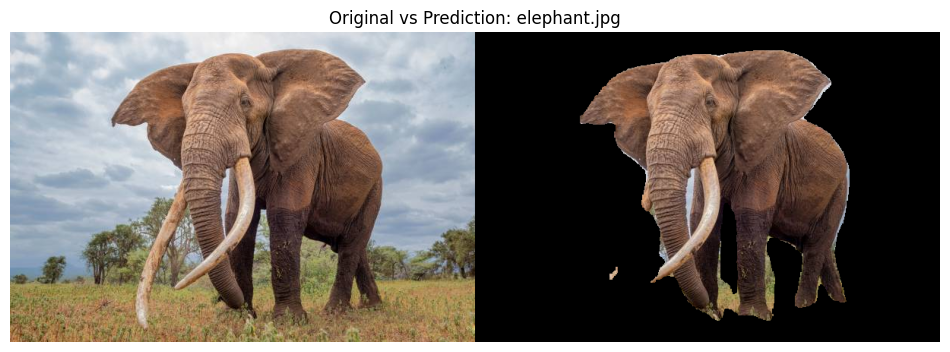

Processed: elephant.jpg


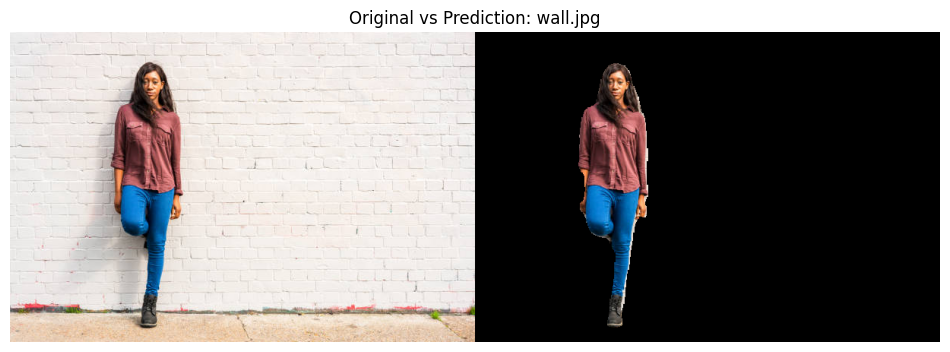

Processed: wall.jpg


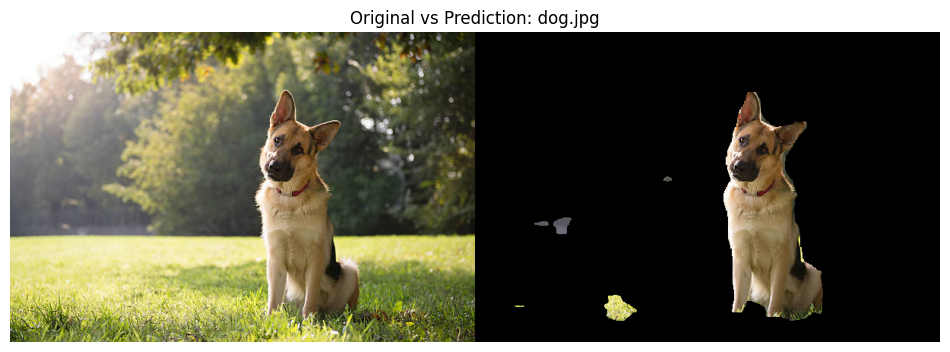

Processed: dog.jpg


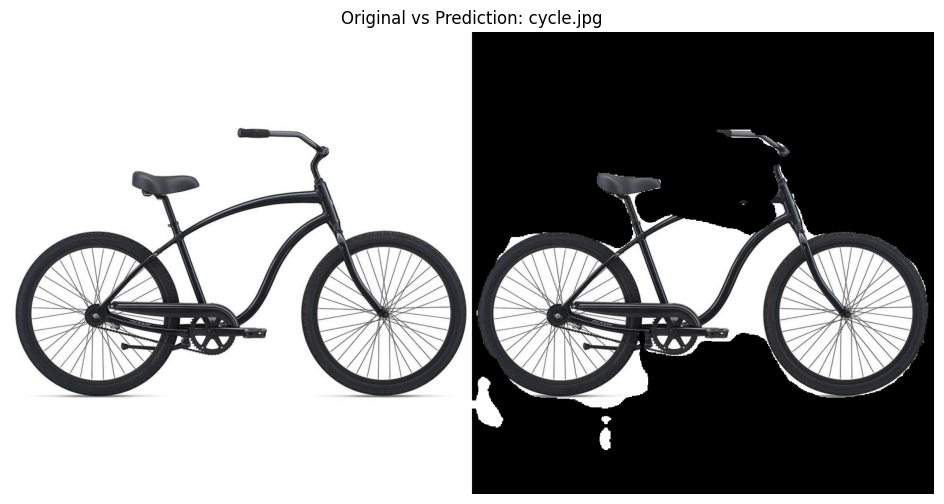

Processed: cycle.jpg


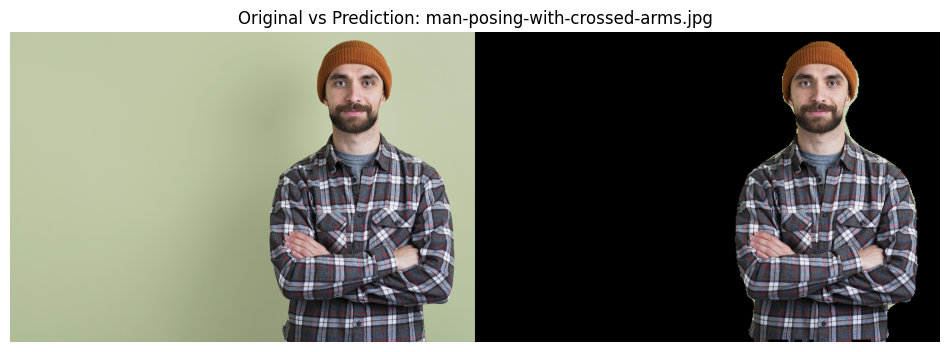

Processed: man-posing-with-crossed-arms.jpg


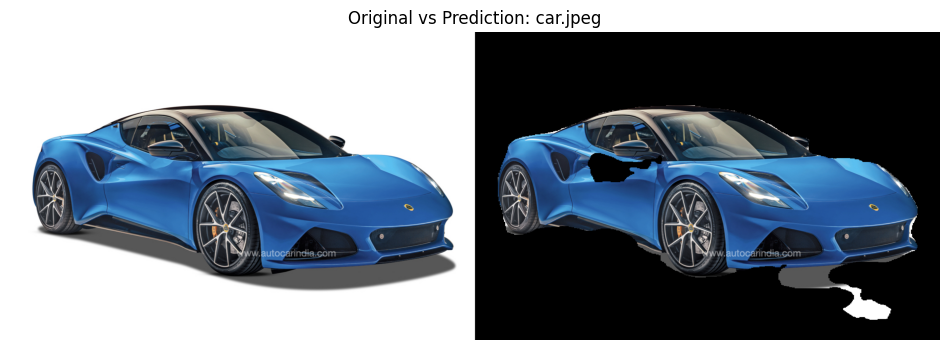

Processed: car.jpeg
All images processed! Side-by-side comparison images saved in 'predictions' folder.


In [50]:
import os
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt

# ------------------- Paths -------------------
images_folder = "/content/drive/MyDrive/AI-Vision/images"
pred_folder = "/content/drive/MyDrive/AI-VISION/predictions/"
os.makedirs(pred_folder, exist_ok=True)

# ------------------- List images -------------------
image_files = [f for f in os.listdir(images_folder) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

# ------------------- Set model to eval -------------------
model.eval()

# ------------------- Loop over images -------------------
for img_name in image_files:
    img_path = os.path.join(images_folder, img_name)

    # Load original image
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    orig_h, orig_w = img.shape[:2]

    # Resize for model input
    img_resized = cv2.resize(img, (512, 512))

    # Convert to tensor
    input_tensor = torch.from_numpy(img_resized).permute(2, 0, 1).float() / 255.0
    input_tensor = input_tensor.unsqueeze(0).to(device)

    # Predict
    with torch.no_grad():
        output = model(input_tensor)['out']
        pred_mask = torch.argmax(output.squeeze(), dim=0).cpu().numpy()

    # Clean mask using morphological operations
    kernel = np.ones((3,3), np.uint8)
    pred_mask = cv2.morphologyEx(pred_mask.astype(np.uint8), cv2.MORPH_OPEN, kernel)
    pred_mask = cv2.morphologyEx(pred_mask, cv2.MORPH_CLOSE, kernel)

    # Resize mask back to original image size
    pred_mask_orig = cv2.resize(pred_mask, (orig_w, orig_h), interpolation=cv2.INTER_NEAREST)

    # Create foreground-extracted image
    binary_mask = (pred_mask_orig > 0).astype(np.uint8)
    extracted = img * binary_mask[:, :, np.newaxis]

    # ------------------- Side-by-side visualization -------------------
    combined = np.concatenate((img, extracted), axis=1)  # original | prediction

    # Display in Colab
    plt.figure(figsize=(12,6))
    plt.imshow(combined)
    plt.axis('off')
    plt.title(f"Original vs Prediction: {img_name}")
    plt.show()

    # Save combined image
    combined_path = os.path.join(pred_folder, img_name.replace('.jpg','_comparison.png'))
    cv2.imwrite(combined_path, cv2.cvtColor(combined, cv2.COLOR_RGB2BGR))

    print(f"Processed: {img_name}")

print("All images processed! Side-by-side comparison images saved in 'predictions' folder.")
